# TT-22 — MLP Regressor: Du doan muc tieu hao nhien lieu de tu van chon xe

**Bai toan:** trang tu van mua xe muon hien thi *"Voi thong so nay, xe tieu hao
khoang 8,5 L/100km — tuong duong ~30 trieu tien xang/nam neu chay 15.000 km"*.
Khach so sanh duoc CHI PHI SU DUNG THAT giua cac mau xe, khong chi nhin gia ban.

**Du lieu:** Auto MPG (UCI) — 398 mau xe (1970–1982), nhan `mpg` (so dam di
duoc tren 1 gallon xang: cang CAO cang TIET KIEM).

**Vi sao thu MLP?** Quan he vat ly giua trong luong/cong suat va tieu hao
nhien lieu la TRON va LIEN TUC (xe nang hon mot chut -> ton xang hon mot chut).
Cay quyet dinh tao ham BAC THANG; MLP tao ham MUOT — ve ly thuyet hop hon.
Nhung bo chi co **398 dong** — rat it cho mang no-ron. Cau hoi trung tam cua
bai: **voi du lieu bang nho, MLP co dang dung khong?**

### Mach logic cua notebook

| Muc | Cau hoi tra loi | Buoc README |
|---|---|---|
| 0 | MLP hoi quy khac MLP phan loai o dau? Vi sao output KHONG activation? | muc 1 |
| 1–2 | Du lieu co van de gi (`?`, `origin`, `car_name`)? | 1, 2 |
| 3 | Quan he weight/model_year vs mpg trong ra sao? | 3 |
| 4 | Moc so sanh: Dummy / Linear / Random Forest | 4 |
| 5 | Khong scale / scale X / scale ca X va y | 5, 6 ✅ |
| 6 | 4 kien truc — mang to co overfit khong? | 7 ✅ |
| 7 | Doc `loss_curve_` va `validation_scores_` | 8 ✅ |
| 8 | Do `alpha` (regularization) | 9 ✅ |
| 9 | relu / tanh / logistic | 10 ✅ |
| 10 | ⭐ MLP vs Linear / RF / SVR / KNN | 11 ✅ |
| 11 | Doi sang L/100km + tien xang/nam | 12 ✅ |
| 12–13 | Luu model, ket luan trung thuc | san pham nop |

## 0. MLP cho hoi quy — khac gi MLP phan loai (TT-10)?

```
   Input (9)      Hidden (64 ReLU)   Hidden (32 ReLU)   Output (1, KHONG activation)
      ○ ───────────── ○ ───────────────── ○ ─────────────── ○  →  mpg
```

| | MLP phan loai | MLP hoi quy |
|---|---|---|
| Tang output | K neuron + softmax/sigmoid | **1 neuron, identity** (ŷ = w·h + b) |
| Dau ra | xac suat trong [0, 1] | so thuc bat ky |
| Loss | cross-entropy | **MSE** = trung binh (y − ŷ)² |

Moi neuron an tinh $h = \text{ReLU}(W x + b)$; tang cuoi chi la to hop tuyen
tinh cua cac $h$. Chinh cac ReLU "be gay" nhieu doan thang ghep lai tao ra
duong cong muot — nhung tang CUOI phai de tuyen tinh de xuat duoc 10, 25, 45 mpg.

Cell duoi chung minh bang so vi sao **dat sigmoid o output la loi kinh dien**:

In [1]:
%matplotlib inline
import json
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RepeatedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

BASE_DIR = Path.cwd().parent
REPORTS_DIR = BASE_DIR / "reports"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR.mkdir(exist_ok=True)
sys.path.append(str(BASE_DIR / "src"))
from features import (CAT_COLS, NUM_COLS, TARGET, load_raw, clean, split_xy,  # noqa: E402
                      make_preprocessor, mpg_to_l100km)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# ConvergenceWarning se xuat hien o thi nghiem "khong scale" - ta tu ghi nhan bang n_iter_
warnings.filterwarnings("ignore", category=ConvergenceWarning)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


sigmoid = lambda z: 1 / (1 + np.exp(-z))
z = np.array([-10, -1, 0, 1, 10, 100])
print("z          :", z)
print("sigmoid(z) :", np.round(sigmoid(z), 4), " -> khong bao gio vuot 1")
print("identity(z):", z, " -> xuat duoc 35 mpg")

z          : [-10  -1   0   1  10 100]
sigmoid(z) : [0.     0.2689 0.5    0.7311 1.     1.    ]  -> khong bao gio vuot 1
identity(z): [-10  -1   0   1  10 100]  -> xuat duoc 35 mpg


**Giai thich code:** cell nap thu vien va import tu `src/features.py` cac ham
dung chung voi `src/train.py` (doc file, lam sach, bo tien xu ly). Dong
`warnings.filterwarnings` tat canh bao "chua hoi tu" — ta se TU do bang
`n_iter_` thay vi de canh bao lam roi output.

**Doc ket qua:** sigmoid ep moi dau vao ve (0, 1) — mang dung sigmoid o output
se khong bao gio doan duoc 35 mpg du train bao lau. `MLPRegressor` cua sklearn
tu dong dung output `identity` (se kiem tra lai bang `out_activation_` o muc 5).

## 1. Doc du lieu — van de `?` o `horsepower`

File goc UCI (`data/auto-mpg.data`) khong co header: 8 cot so cach nhau bang
khoang trang, sau do la TAB va ten xe trong ngoac kep. `load_raw()` doc tung
dong, tach theo TAB, giu moi cot dang CHUOI de thay dung van de.

In [2]:
df_raw = load_raw()
print(f"Kich thuoc: {df_raw.shape[0]} dong x {df_raw.shape[1]} cot")
print("So gia tri '?' moi cot:", (df_raw == "?").sum()[lambda s: s > 0].to_dict())
df_raw[df_raw["horsepower"] == "?"]

Kich thuoc: 398 dong x 9 cot
So gia tri '?' moi cot: {'horsepower': 6}


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.00,?,2046.,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875.,17.0,74,1,ford maverick
330,40.9,4,85.00,?,1835.,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905.,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320.,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035.,20.5,82,1,amc concord dl


**Doc ket qua:** dung 6 xe thieu `horsepower`, ghi bang ky tu `?`. Neu doc
bang `pd.read_csv` binh thuong, CA COT `horsepower` se thanh kieu chu (object)
chi vi 6 o nay — mo hinh se loi hoac bo qua cot quan trong.

## 2. Lam sach: ep kieu, one-hot `origin`, bo `car_name`

| Van de | Cach xu ly | Vi sao |
|---|---|---|
| `?` o horsepower | `pd.to_numeric(errors="coerce")` -> NaN, roi `SimpleImputer(median)` TRONG pipeline | Median hoc tu TRAIN, khong nhin test (tranh ro ri) |
| `origin` = 1/2/3 | doi thanh ten vung, roi `OneHotEncoder` | Neu de so, model hieu "Nhat (3) > Chau Au (2) > My (1)" — vo nghia |
| `car_name` | bo | Dinh danh gan nhu duy nhat tung xe, khong tong quat hoa duoc |

**Giai thich code `make_preprocessor(scale)`:** mot `ColumnTransformer` xu ly
rieng 2 nhom cot — 6 cot so: dien median (+ `StandardScaler` neu `scale=True`);
cot `origin`: one-hot thanh 3 cot 0/1. Tong cong 6 + 3 = **9 dau vao** cho mang.
Tham so `scale` cho phep tao ban KHONG chuan hoa de lam thi nghiem muc 5.

In [3]:
df = clean(df_raw)
print(df.dtypes.to_string())
print("\nSo NaN:", df.isna().sum()[lambda s: s > 0].to_dict())
print("Phan bo origin:", df["origin"].value_counts().to_dict())

X, y = split_xy(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"\nTrain: {len(X_train)}  Test: {len(X_test)}")

pre = make_preprocessor(scale=True).fit(X_train)
print("Cac cot sau tien xu ly:", list(pre.get_feature_names_out()))

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin              str

So NaN: {'horsepower': 6}
Phan bo origin: {'My': 249, 'Nhat': 79, 'Chau_Au': 70}

Train: 318  Test: 80
Cac cot sau tien xu ly: ['num__cylinders', 'num__displacement', 'num__horsepower', 'num__weight', 'num__acceleration', 'num__model_year', 'cat__origin_Chau_Au', 'cat__origin_My', 'cat__origin_Nhat']


**Luu y quan trong ve kich thuoc:** tap test chi co **80 xe** — 1 vai xe kho
doan cung du lam RMSE test dao dong. Vi vay tu muc 4, ngoai RMSE test ta con
bao cao **RMSE cross-validation 5-fold tren tap train** (trung binh 5 lan
danh gia) de so sanh cac cau hinh on dinh hon. Tap test chi dung de bao cao.

## 3. EDA: weight vs mpg, mpg theo model_year

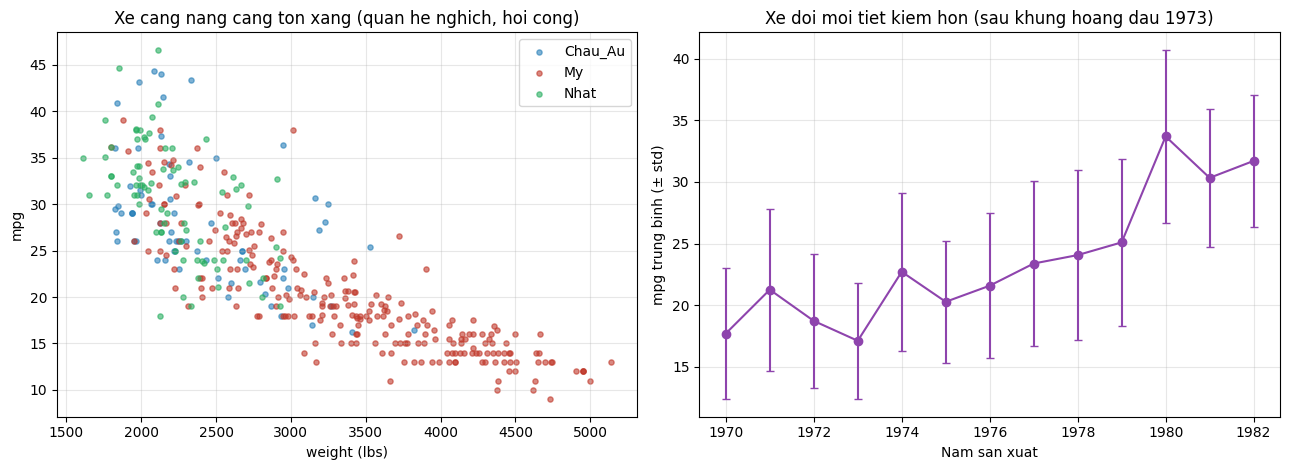

weight         -0.832
displacement   -0.804
horsepower     -0.778
cylinders      -0.775
acceleration    0.420
model_year      0.579


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
mau = {"My": "#c0392b", "Chau_Au": "#2980b9", "Nhat": "#27ae60"}
for o, g in df.groupby("origin"):
    axes[0].scatter(g["weight"], g["mpg"], s=14, alpha=0.6, color=mau[o], label=o)
axes[0].set_xlabel("weight (lbs)"); axes[0].set_ylabel("mpg"); axes[0].legend()
axes[0].set_title("Xe cang nang cang ton xang (quan he nghich, hoi cong)")

tb = df.groupby("model_year")["mpg"].agg(["mean", "std"])
axes[1].errorbar(tb.index + 1900, tb["mean"], yerr=tb["std"], marker="o", capsize=3, color="#8e44ad")
axes[1].set_xlabel("Nam san xuat"); axes[1].set_ylabel("mpg trung binh (± std)")
axes[1].set_title("Xe doi moi tiet kiem hon (sau khung hoang dau 1973)")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda.png", dpi=110)
plt.show()

print(df[NUM_COLS + [TARGET]].corr()[TARGET].drop(TARGET).round(3).sort_values().to_string())

**Doc ket qua:**
- `weight` vs `mpg`: nghich bien manh (tuong quan ~ −0,83) va **cong** — tu
  2.000 len 3.000 lbs mpg giam nhanh, tu 4.000 len 5.000 lbs giam cham. Duong
  thang (Linear Regression) se sai co he thong o 2 dau -> day la cho MLP (ham
  muot, phi tuyen) co the hon Linear.
- `model_year`: mpg tang ro sau 1973 (khung hoang dau + tieu chuan tiet kiem
  nhien lieu CAFE cua My) — dac trung nay KHONG trung lap voi weight.
- Xe Nhat/Chau Au nhe va tiet kiem hon xe My -> `origin` mang thong tin, nhung
  phan lon da "chua" trong weight/cylinders.
- `cylinders`, `displacement`, `horsepower`, `weight` tuong quan rat cao voi
  nhau (cung do "do lon dong co") -> da cong tuyen, Linear bi anh huong he so,
  nhung mang no-ron/cay khong qua bi.

## 4. Baseline: Dummy + Linear Regression + Random Forest

**Giai thich code `danh_gia()`:** ham dung chung cho MOI thi nghiem de so sanh
cong bang. No (1) do thoi gian `fit` tren train, (2) tinh RMSE train va test,
R² test, (3) chay `cross_val_score` 5-fold tren TAP TRAIN (model duoc `clone`
va fit lai tu dau o moi fold, nen khong anh huong model vua fit).
Moi model deu la `Pipeline(tien xu ly -> model)` de buoc impute/one-hot/scale
chi hoc tu phan du lieu dung de train o moi fold.

In [5]:
cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def danh_gia(model, ten, cv=cv5):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    t_train = time.perf_counter() - t0
    p_tr, p_te = model.predict(X_train), model.predict(X_test)
    cv_scores = -cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
    return {"Model": ten, "RMSE_train": rmse(y_train, p_tr), "RMSE_test": rmse(y_test, p_te),
            "R2_test": r2_score(y_test, p_te), "RMSE_CV": cv_scores.mean(), "RMSE_CV_std": cv_scores.std(),
            "Train_s": t_train}


baseline = pd.DataFrame([
    danh_gia(Pipeline([("pre", make_preprocessor()), ("m", DummyRegressor())]), "Dummy (trung binh)"),
    danh_gia(Pipeline([("pre", make_preprocessor()), ("m", LinearRegression())]), "Linear Regression"),
    danh_gia(Pipeline([("pre", make_preprocessor()),
                       ("m", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]),
             "Random Forest"),
]).set_index("Model")
baseline.round(3)

,RMSE_train,RMSE_test,R2_test,RMSE_CV,RMSE_CV_std,Train_s
Model,,,,,,
Dummy (trung binh),7.918,7.347,-0.004,7.923,0.557,0.007
Linear Regression,3.370,2.888,0.845,3.478,0.224,0.006
Random Forest,1.078,2.157,0.913,2.966,0.107,0.273


**Doc ket qua:** Dummy RMSE ~7,5 mpg (do lech chuan cua mpg). Linear da cat
giam hon mot nua (R² ~0,8+); Random Forest tot hon Linear ro rang — xac nhan
co quan he phi tuyen ma duong thang bo lo. RMSE train cua Random Forest rat
thap (moi cay gan nhu thuoc long train) nhung RMSE CV van tot — rung cay tu
"chong overfit" nho lay trung binh nhieu cay. **Moc MLP can vuot: Random Forest.**

## 5. ⚠️ Ba truong hop scale: khong scale / chi X / ca X va y

**Logic:**
- **Khong scale X:** `weight` ~ 2.000–5.000 trong khi dau vao one-hot la 0/1.
  Trong so khoi tao nho, nhan voi 4.000 -> tin hieu cuc lon, ReLU bao hoa hoac
  gradient cua `weight` ap dao — Adam phai "leo" rat lau, hay ket.
- **Chi scale X:** dau vao da on, nhung mang phai hoc output quanh 10–45 tu
  trong so khoi tao quanh 0 — tang cuoi phai tu "keo" bias len ~23.
- **Scale ca y** (`TransformedTargetRegressor`): mang hoc y da chuan hoa
  (trung binh 0, std 1), luc du doan tu dong bien doi NGUOC ve mpg. Gradient
  cua MSE cung co do lon hop ly -> hoi tu nhanh, on dinh.

**Giai thich code:** `lam_mlp()` tao MLP theo cau hinh README. `TransformedTargetRegressor(regressor=pipe,
transformer=StandardScaler())` boc ngoai pipeline: khi `fit` no scale y roi
moi dua vao pipeline; khi `predict` no goi `inverse_transform` — ta KHONG phai
tu viet buoc doi nguoc. `lay_mlp()` lay ra MLP ben trong (qua 1 hoac 2 lop boc)
de doc `n_iter_`, `loss_curve_`...

In [6]:
def lam_mlp(hidden=(64, 32), alpha=1e-2, activation="relu", early_stopping=True,
            max_iter=2000, n_iter_no_change=30, seed=RANDOM_STATE):
    return MLPRegressor(hidden_layer_sizes=hidden, activation=activation, solver="adam",
                        alpha=alpha, learning_rate_init=1e-3, max_iter=max_iter,
                        early_stopping=early_stopping, n_iter_no_change=n_iter_no_change,
                        random_state=seed)


def mlp_pipe(scale_x=True, scale_y=True, **kw):
    pipe = Pipeline([("pre", make_preprocessor(scale=scale_x)), ("mlp", lam_mlp(**kw))])
    return TransformedTargetRegressor(regressor=pipe, transformer=StandardScaler()) if scale_y else pipe


def lay_mlp(model):
    pipe = model.regressor_ if isinstance(model, TransformedTargetRegressor) else model
    return pipe.named_steps["mlp"]


rows = []
for ten, sx, sy in [("Khong scale", False, False), ("Chi scale X", True, False), ("Scale X va y", True, True)]:
    m = mlp_pipe(scale_x=sx, scale_y=sy)
    r = danh_gia(m, ten)
    r["n_iter"] = lay_mlp(m).n_iter_
    rows.append(r)
bang_scale = pd.DataFrame(rows).set_index("Model")
bang_scale.to_csv(REPORTS_DIR / "so_sanh_scale.csv")
print("Activation tang output:", lay_mlp(m).out_activation_)
bang_scale.round(3)

Activation tang output: identity


,RMSE_train,RMSE_test,R2_test,RMSE_CV,RMSE_CV_std,Train_s,n_iter
Model,,,,,,,
Khong scale,3.799,3.113,0.820,3.722,0.204,0.232,235
Chi scale X,2.692,2.364,0.896,3.001,0.167,0.342,342
Scale X va y,2.023,2.190,0.911,2.995,0.146,0.284,247


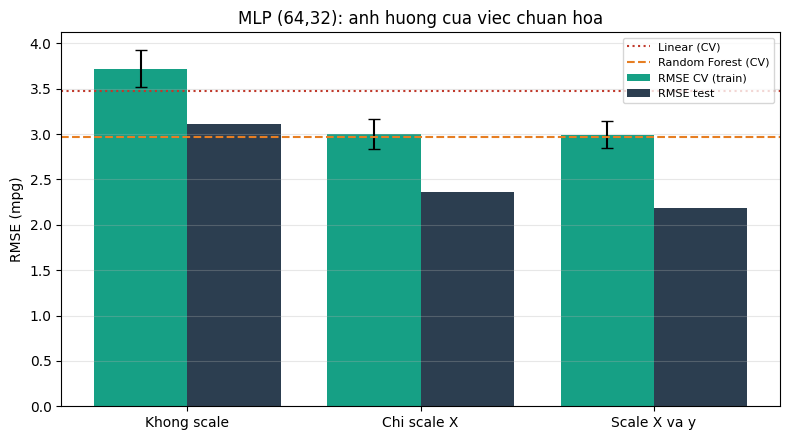

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.arange(len(bang_scale))
ax.bar(xs - 0.2, bang_scale["RMSE_CV"], 0.4, yerr=bang_scale["RMSE_CV_std"], capsize=4, label="RMSE CV (train)", color="#16a085")
ax.bar(xs + 0.2, bang_scale["RMSE_test"], 0.4, label="RMSE test", color="#2c3e50")
ax.axhline(baseline.loc["Linear Regression", "RMSE_CV"], color="#c0392b", ls=":", label="Linear (CV)")
ax.axhline(baseline.loc["Random Forest", "RMSE_CV"], color="#e67e22", ls="--", label="Random Forest (CV)")
ax.set_xticks(xs); ax.set_xticklabels(bang_scale.index); ax.set_ylabel("RMSE (mpg)")
ax.set_title("MLP (64,32): anh huong cua viec chuan hoa"); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "scale_comparison.png", dpi=110); plt.show()

**Doc ket qua:**
- `out_activation_ = 'identity'` — sklearn tu dat output tuyen tinh cho hoi quy.
- **Khong scale:** te nhat, RMSE CV ~3,7 — THUA ca Linear Regression (~3,5) du
  cung kien truc. Early stopping dung som vi validation khong cai thien: mang
  "ket" chu khong phai hoi tu.
- **Chi scale X:** cai thien lon nhat (RMSE CV ~3,0) — day la buoc quyet dinh.
- **Scale ca X va y:** RMSE CV ngang scale X, nhung RMSE train/test thap hon
  va can IT vong lap hon (`n_iter` ~250 so voi ~340): mang khong phai ton cong
  "keo" output tu ~0 len ~23 mpg, gradient co do lon hop ly.
- Bai hoc: voi mang no-ron, **scale X la bat buoc, scale y la nen lam**. Tu day
  moi MLP deu scale ca X va y.

## 6. Bon kien truc: (16) · (64) · (64,32) · (256,128,64)

**Logic:** so tham so cua mang = tong (so dau vao × so neuron + bias) qua cac
tang. Mang (256,128,64) co ~44.000 tham so de hoc tu 318 xe — hon 100 tham so
cho moi mau! Ly thuyet: mang du lon co the "thuoc long" toan bo tap train.

Chay moi kien truc o **2 che do**:
- **Co regularization** (cau hinh README): `alpha=1e-2` + `early_stopping`
- **Khong regularization:** `alpha=1e-5`, KHONG early stopping, cho chay toi
  3.000 vong — de thay mang to that su lam gi khi khong bi kiem che.

**Giai thich code:** `so_tham_so()` cong kich thuoc moi ma tran trong so
`coefs_` va vector bias `intercepts_` cua MLP da train. "Khoang cach overfit"
= RMSE_test − RMSE_train: cang lon cang overfit.

In [8]:
def so_tham_so(mlp):
    return int(sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_))


kien_truc = [(16,), (64,), (64, 32), (256, 128, 64)]
rows = []
for h in kien_truc:
    for che_do, kw in [("Co regularization", dict(alpha=1e-2, early_stopping=True)),
                       ("Khong regularization", dict(alpha=1e-5, early_stopping=False, max_iter=3000))]:
        m = mlp_pipe(hidden=h, **kw)
        r = danh_gia(m, str(h))
        r.update({"Che_do": che_do, "So_tham_so": so_tham_so(lay_mlp(m)), "n_iter": lay_mlp(m).n_iter_})
        r["Gap_overfit"] = r["RMSE_test"] - r["RMSE_train"]
        rows.append(r)

bang_kt = pd.DataFrame(rows)
cols = ["Che_do", "Model", "So_tham_so", "n_iter", "RMSE_train", "RMSE_test", "Gap_overfit", "RMSE_CV", "RMSE_CV_std", "R2_test"]
bang_kt = bang_kt[cols].rename(columns={"Model": "Kien_truc"})
bang_kt.to_csv(REPORTS_DIR / "so_sanh_kien_truc.csv", index=False)
bang_kt.round(3)

,Che_do,Kien_truc,So_tham_so,n_iter,RMSE_train,RMSE_test,Gap_overfit,RMSE_CV,RMSE_CV_std,R2_test
0,Co regularization,"(16,)",177,335,2.843,2.611,-0.231,3.240,0.183,0.873
1,Khong regularization,"(16,)",177,295,2.846,2.582,-0.264,3.070,0.219,0.876
2,Co regularization,"(64,)",705,345,2.370,2.169,-0.201,2.982,0.184,0.912
3,Khong regularization,"(64,)",705,304,2.355,2.131,-0.224,2.912,0.180,0.916
4,Co regularization,"(64, 32)",2753,247,2.023,2.190,0.167,2.995,0.146,0.911
5,Khong regularization,"(64, 32)",2753,568,1.407,2.503,1.096,2.965,0.229,0.883
6,Co regularization,"(256, 128, 64)",43777,97,1.978,2.237,0.259,2.869,0.301,0.907
7,Khong regularization,"(256, 128, 64)",43777,520,0.716,2.617,1.901,3.148,0.156,0.873


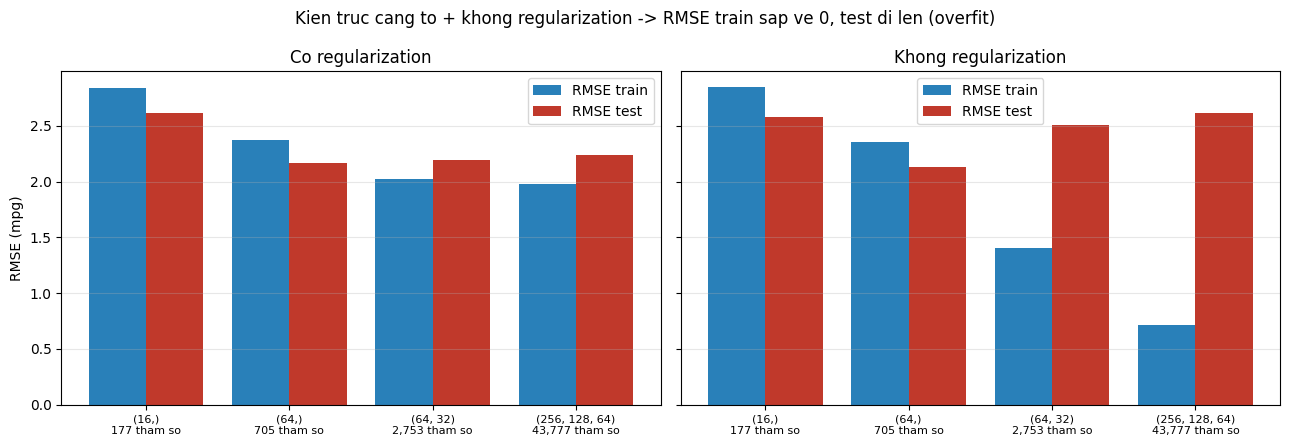

CV tot nhat: (256, 128, 64) RMSE_CV=2.869 ± 0.301 -> nguong 3.170
Cac kien truc dat nguong: ['(64,)', '(64, 32)', '(256, 128, 64)']
-> Chon kien truc NHO NHAT dat nguong: (64,)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, che_do in zip(axes, ["Co regularization", "Khong regularization"]):
    b = bang_kt[bang_kt["Che_do"] == che_do]
    xs = np.arange(len(b))
    ax.bar(xs - 0.2, b["RMSE_train"], 0.4, label="RMSE train", color="#2980b9")
    ax.bar(xs + 0.2, b["RMSE_test"], 0.4, label="RMSE test", color="#c0392b")
    ax.set_xticks(xs)
    ax.set_xticklabels([f"{k}\n{p:,} tham so" for k, p in zip(b["Kien_truc"], b["So_tham_so"])], fontsize=8)
    ax.set_title(che_do); ax.grid(alpha=0.3, axis="y"); ax.legend()
axes[0].set_ylabel("RMSE (mpg)")
fig.suptitle("Kien truc cang to + khong regularization -> RMSE train sap ve 0, test di len (overfit)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "kien_truc_overfit.png", dpi=110); plt.show()

# Quy tac "1 do lech chuan" (1-SE): trong cac kien truc co RMSE CV khong te hon
# (tot nhat + 1 std cua no), chon kien truc IT tham so nhat.
reg = bang_kt[bang_kt["Che_do"] == "Co regularization"]
tot_nhat = reg.loc[reg["RMSE_CV"].idxmin()]
nguong = tot_nhat["RMSE_CV"] + tot_nhat["RMSE_CV_std"]
dat = reg[reg["RMSE_CV"] <= nguong].sort_values("So_tham_so")
best_arch = eval(dat.iloc[0]["Kien_truc"])
print(f"CV tot nhat: {tot_nhat['Kien_truc']} RMSE_CV={tot_nhat['RMSE_CV']:.3f} ± {tot_nhat['RMSE_CV_std']:.3f} -> nguong {nguong:.3f}")
print("Cac kien truc dat nguong:", list(dat["Kien_truc"]))
print("-> Chon kien truc NHO NHAT dat nguong:", best_arch)

**Doc ket qua — chung minh mang to overfit voi du lieu nho:**
- **Khong regularization:** cang to, RMSE train cang giam manh (mang
  (256,128,64) gan nhu thuoc long train) nhung RMSE test lai TANG — khoang
  cach overfit phinh to. Mang nho (16) thi train ~ test (khong du suc overfit).
- **Co regularization** (`alpha` + early stopping): khoang cach thu hep han,
  ca mang to cung khong con te — regularization "kiem che" suc chua thua.
- Co regularization, mang to cho RMSE CV nhinh nhat — nhung hon mang vua
  chi mot khoang NHO HON do lech chuan giua cac fold, tuc la trong pham vi
  nhieu. Voi 318 mau, 44.000 tham so la suc chua thua: loi ich khong chac
  chan, rui ro (overfit khi quen regularize, cham, kem on dinh) thi co that.
- **Chon kien truc theo quy tac 1-SE:** lay mang NHO NHAT co RMSE CV nam
  trong (tot nhat + 1 std). Day la cach chon pho bien khi cac ung vien "hoa
  nhau" ve thong ke — uu tien mo hinh don gian hon.

## 7. Chan doan bang `loss_curve_` va `validation_scores_`

- `loss_curve_`: loss (MSE/2 + phat alpha) tren tap train sau MOI vong (epoch).
- `validation_scores_`: R² tren 10% tap train duoc tach ra lam validation
  (chi co khi `early_stopping=True`).

**Giai thich code:** de thay TOAN BO qua trinh (ke ca doan sau diem toi uu),
cho mang to khong regularization chay voi `early_stopping=True` nhung
`n_iter_no_change` = so vong toi da — tuc la van ghi validation nhung KHONG
dung som. Doi chieu voi mang (64,32) cau hinh README (dung som that).

(64,32) alpha=1e-2, dung som             so vong=  247  R2 val tot nhat=0.877 o vong 244  R2 val cuoi=0.876
(256,128,64) alpha=1e-5, khong dung      so vong= 1500  R2 val tot nhat=0.936 o vong 65  R2 val cuoi=0.850


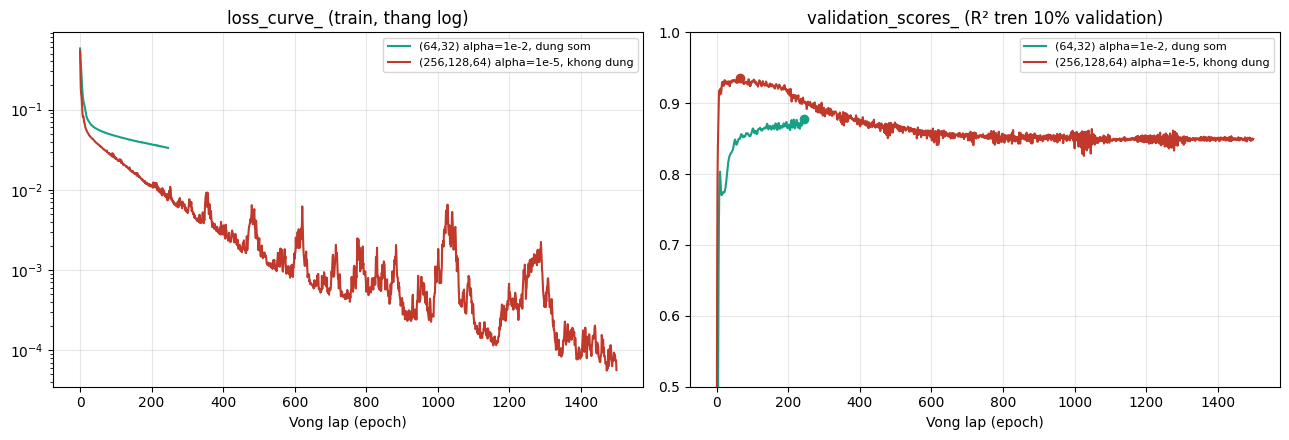

In [10]:
m_nho = mlp_pipe(hidden=(64, 32), alpha=1e-2, early_stopping=True).fit(X_train, y_train)
m_to = mlp_pipe(hidden=(256, 128, 64), alpha=1e-5, early_stopping=True,
                max_iter=1500, n_iter_no_change=1500).fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for m, ten, mau_ in [(m_nho, "(64,32) alpha=1e-2, dung som", "#16a085"),
                     (m_to, "(256,128,64) alpha=1e-5, khong dung", "#c0392b")]:
    mlp = lay_mlp(m)
    axes[0].plot(mlp.loss_curve_, color=mau_, label=ten)
    axes[1].plot(mlp.validation_scores_, color=mau_, label=ten)
    best_ep = int(np.argmax(mlp.validation_scores_))
    axes[1].scatter(best_ep, mlp.validation_scores_[best_ep], color=mau_, zorder=5)
    print(f"{ten:40s} so vong={mlp.n_iter_:5d}  R2 val tot nhat={max(mlp.validation_scores_):.3f} "
          f"o vong {best_ep}  R2 val cuoi={mlp.validation_scores_[-1]:.3f}")
axes[0].set_yscale("log"); axes[0].set_title("loss_curve_ (train, thang log)"); axes[0].set_xlabel("Vong lap (epoch)")
axes[1].set_title("validation_scores_ (R² tren 10% validation)"); axes[1].set_xlabel("Vong lap (epoch)")
axes[1].set_ylim(0.5, 1)
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "loss_curve.png", dpi=110); plt.show()

**Doc ket qua (chan doan):**
- Mang to: loss train giam MAI (thang log, tien ve rat nho), nhung R² validation
  dat dinh kha som roi **di ngang/giam dan** — dau hieu overfit kinh dien:
  "cang train cang thuoc bai, nhung khong gioi hon tren du lieu moi".
- Mang (64,32) co early stopping: dung lai ngay khi validation khong con cai
  thien sau 30 vong — tiet kiem thoi gian va tranh doan overfit.
- Luu y: validation chi co ~32 xe, nen duong R² kha rang cua — mot ly do nua
  de dung `n_iter_no_change` du lon (30) thay vi dung ngay khi tut lan dau.

## 8. Do `alpha` ∈ {1e-4, 1e-3, 1e-2, 1e-1} (+ 1, 10 de thay underfit)

**Logic:** `alpha` la he so phat L2: loss = MSE/2 + alpha × Σw² / (2n). Alpha lon
-> ep trong so nho -> ham muot hon, it overfit; qua lon -> mang "bi troi tay",
underfit.

**Giai thich code:** de thay RIENG tac dung cua alpha, tat early stopping (neu
khong, dung som cung dang regularize, lam mo hieu ung). Dung kien truc chon o
muc 6. Chon alpha theo RMSE CV. Vi alpha duoc chon trong che do KHONG early
stopping, cac muc sau (activation, model cuoi) cung giu che do nay de nhat quan
— luc do alpha dong vai tro regularization chinh.

alpha tot nhat theo RMSE CV cho (64,): 1
alpha tot nhat theo RMSE CV cho (256, 128, 64): 1


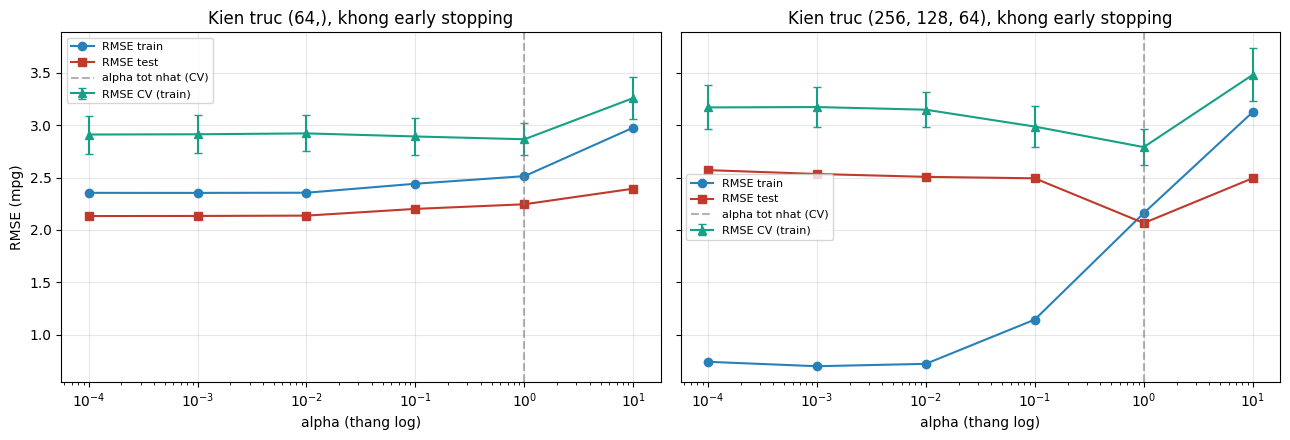

(64,)                   (256, 128, 64)                  
        RMSE_train RMSE_test RMSE_CV     RMSE_train RMSE_test RMSE_CV
alpha                                                                
0.0001       2.355     2.133   2.911          0.741     2.572   3.170
0.0010       2.354     2.134   2.914          0.699     2.535   3.174
0.0100       2.356     2.137   2.922          0.722     2.507   3.149
0.1000       2.442     2.201   2.893          1.144     2.493   2.987
1.0000       2.514     2.246   2.866          2.161     2.066   2.791
10.0000      2.978     2.395   3.260          3.126     2.495   3.482

In [11]:
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
KT_TO = (256, 128, 64)


def quet_alpha(hidden):
    rows = []
    for a in alphas:
        r = danh_gia(mlp_pipe(hidden=hidden, alpha=a, early_stopping=False, max_iter=2000), f"alpha={a:g}")
        r["alpha"] = a
        rows.append(r)
    return pd.DataFrame(rows).set_index("alpha")


bang_alpha = quet_alpha(best_arch)      # kien truc duoc chon -> dung de chon alpha
bang_alpha_to = quet_alpha(KT_TO)       # mang to -> de thay RO tac dung cua alpha
best_alpha = float(bang_alpha["RMSE_CV"].idxmin())
print(f"alpha tot nhat theo RMSE CV cho {best_arch}: {best_alpha:g}")
print(f"alpha tot nhat theo RMSE CV cho {KT_TO}: {float(bang_alpha_to['RMSE_CV'].idxmin()):g}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, b, kt in [(axes[0], bang_alpha, best_arch), (axes[1], bang_alpha_to, KT_TO)]:
    ax.plot(alphas, b["RMSE_train"], marker="o", label="RMSE train", color="#2980b9")
    ax.plot(alphas, b["RMSE_test"], marker="s", label="RMSE test", color="#c0392b")
    ax.errorbar(alphas, b["RMSE_CV"], yerr=b["RMSE_CV_std"], marker="^", capsize=3, label="RMSE CV (train)", color="#16a085")
    ax.axvline(float(b["RMSE_CV"].idxmin()), color="gray", ls="--", alpha=0.6, label="alpha tot nhat (CV)")
    ax.set_xscale("log"); ax.set_xlabel("alpha (thang log)"); ax.set_title(f"Kien truc {kt}, khong early stopping")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel("RMSE (mpg)")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "alpha_sweep.png", dpi=110); plt.show()
pd.concat({str(best_arch): bang_alpha[["RMSE_train", "RMSE_test", "RMSE_CV"]],
           str(KT_TO): bang_alpha_to[["RMSE_train", "RMSE_test", "RMSE_CV"]]}, axis=1).round(3)

**Doc ket qua — alpha quan trong den dau phu thuoc vao do lon cua mang:**
- **Mang to (256,128,64)** (phai): alpha nho -> RMSE train rat thap (~0,7), khoang
  cach train–test lon = overfit. Tang alpha -> RMSE train tang deu (trong so
  bi ep nho), RMSE CV giam toi day roi tang lai khi alpha qua lon (10: underfit).
  Day la duong chu U bias–variance kinh dien.
- **Mang vua duoc chon** (trai): 4 gia tri alpha cua README (1e-4..1e-1) gan nhu
  KHONG khac nhau — mang nho khong du suc overfit nen khong co gi de "phat".
  Chi alpha rat lon (10) moi lam hong mo hinh.
- Bai hoc: regularization la cong cu de dung mang TO mot cach an toan; neu
  da chon mang vua voi du lieu, alpha chi con la tinh chinh nho.

## 9. So sanh activation: relu / tanh / logistic

- **relu** max(0, z): nhanh, khong bao hoa phia duong — mac dinh hien dai
- **tanh**: (−1, 1), doi xung quanh 0, tron
- **logistic** (sigmoid): (0, 1), de bao hoa -> gradient nho, hoc cham

(Activation nay chi ap cho TANG AN; tang output van la identity.)

In [12]:
rows = []
for act in ["relu", "tanh", "logistic"]:
    m = mlp_pipe(hidden=best_arch, alpha=best_alpha, activation=act, early_stopping=False, max_iter=2000)
    r = danh_gia(m, act)
    r["n_iter"] = lay_mlp(m).n_iter_
    rows.append(r)
bang_act = pd.DataFrame(rows).set_index("Model")
best_act = bang_act["RMSE_CV"].idxmin()
print("Activation tot nhat theo RMSE CV:", best_act)
bang_act[["RMSE_train", "RMSE_test", "RMSE_CV", "R2_test", "n_iter"]].round(3)

Activation tot nhat theo RMSE CV: relu


,RMSE_train,RMSE_test,RMSE_CV,R2_test,n_iter
Model,,,,,
relu,2.514,2.246,2.866,0.906,332
tanh,2.803,2.319,2.974,0.900,533
logistic,3.487,2.889,3.540,0.845,285


**Doc ket qua:** `relu` tot nhat, `tanh` sat sau, `logistic` kem ro (RMSE CV
~3,5 — gan bang Linear Regression). Logistic bao hoa o hai dau (gradient ~0)
va khong doi xung quanh 0, nen voi cung so vong va cung alpha, mang hoc cham
va bi "lam phang" — ly do no gan nhu bien mat khoi tang an cua mang hien dai.

## 10. ⭐ Bang so sanh cuoi: MLP vs Linear (TT-11) vs RF (TT-17) vs SVR (TT-20) vs KNN (TT-21)

Cac TT truoc dung bo du lieu khac, nen **train lai tung thuat toan tren CUNG
bo Auto MPG, CUNG tien xu ly, CUNG chia train/test** moi so sanh cong bang.

**Giai thich code:**
- Dung `RepeatedKFold(5 fold × 3 lan)` = 15 lan danh gia -> trung binh + do
  lech chuan dang tin hon 1 tap test 80 xe.
- SVR va KNN la model dua tren khoang cach nen cung scale X; SVR scale ca y
  (nhu TT-20). SVR duoc tune nhanh C/epsilon bang `GridSearchCV` truoc.
- MLP cuoi dung (kien truc, alpha, activation) chon bang CV o muc 6, 8, 9.

In [13]:
cv_rep = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

svr_grid = GridSearchCV(
    TransformedTargetRegressor(regressor=Pipeline([("pre", make_preprocessor()), ("m", SVR(kernel="rbf"))]),
                               transformer=StandardScaler()),
    {"regressor__m__C": [0.3, 1, 3, 10], "regressor__m__epsilon": [0.05, 0.1, 0.2]},
    cv=cv5, scoring="neg_root_mean_squared_error").fit(X_train, y_train)
print("SVR tham so tot nhat:", svr_grid.best_params_)

mlp_final = mlp_pipe(hidden=best_arch, alpha=best_alpha, activation=best_act, early_stopping=False, max_iter=2000)
ung_vien = {
    "Linear Regression (TT-11)": (Pipeline([("pre", make_preprocessor()), ("m", LinearRegression())]), "Co (he so)"),
    "Random Forest (TT-17)": (Pipeline([("pre", make_preprocessor()),
                                        ("m", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]),
                              "Mot phan (feature importance)"),
    "SVR RBF (TT-20)": (svr_grid.best_estimator_, "Kho"),
    "KNN K=5 distance (TT-21)": (Pipeline([("pre", make_preprocessor()),
                                           ("m", KNeighborsRegressor(n_neighbors=5, weights="distance"))]),
                                 "Co (xe tuong tu)"),
    f"MLP {best_arch} (TT-22)": (mlp_final, "Kho (hop den)"),
}
rows = []
for ten, (m, giai_thich) in ung_vien.items():
    r = danh_gia(m, ten, cv=cv_rep)
    r["Giai_thich"] = giai_thich
    rows.append(r)
so_sanh = pd.DataFrame(rows).set_index("Model")[["RMSE_test", "R2_test", "RMSE_CV", "RMSE_CV_std", "Train_s", "Giai_thich"]]
so_sanh.to_csv(REPORTS_DIR / "so_sanh_models.csv")
so_sanh.sort_values("RMSE_CV").round(3)

SVR tham so tot nhat: {'regressor__m__C': 3, 'regressor__m__epsilon': 0.2}


,RMSE_test,R2_test,RMSE_CV,RMSE_CV_std,Train_s,Giai_thich
Model,,,,,,
SVR RBF (TT-20),1.999,0.926,2.697,0.391,0.013,Kho
"MLP (64,) (TT-22)",2.246,0.906,2.859,0.290,0.184,Kho (hop den)
Random Forest (TT-17),2.157,0.913,2.965,0.346,0.288,Mot phan (feature importance)
KNN K=5 distance (TT-21),2.212,0.909,3.060,0.394,0.006,Co (xe tuong tu)
Linear Regression (TT-11),2.888,0.845,3.470,0.274,0.007,Co (he so)


MLP cuoi (64,), alpha=1                      : RMSE test qua 10 seed = 2.196 ± 0.031  (min 2.149, max 2.262)
MLP to (256, 128, 64), alpha=1e-2 + early stopping: RMSE test qua 10 seed = 2.350 ± 0.385  (min 1.993, max 3.412)


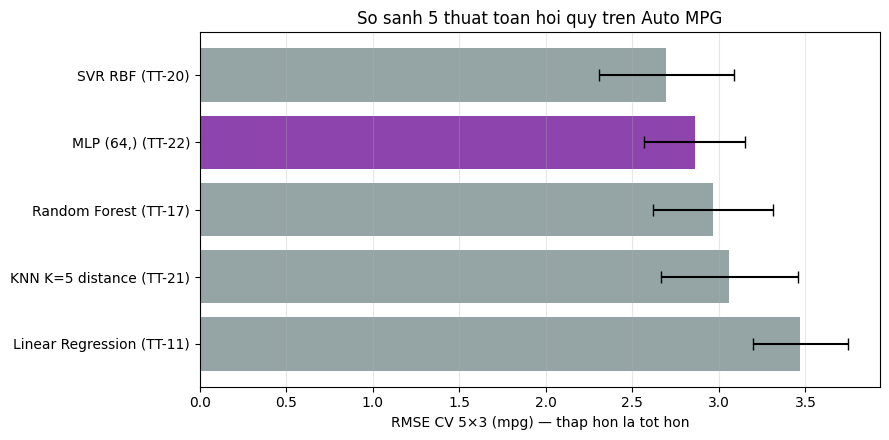

In [14]:
# Do on dinh: cung cau hinh, 10 seed khoi tao khac nhau
def do_on_dinh(**kw):
    kq = [rmse(y_test, mlp_pipe(seed=s, **kw).fit(X_train, y_train).predict(X_test)) for s in range(10)]
    return float(np.mean(kq)), float(np.std(kq)), min(kq), max(kq)


on_dinh = {
    f"MLP cuoi {best_arch}, alpha={best_alpha:g}": do_on_dinh(hidden=best_arch, alpha=best_alpha, activation=best_act,
                                                          early_stopping=False, max_iter=2000),
    f"MLP to {KT_TO}, alpha=1e-2 + early stopping": do_on_dinh(hidden=KT_TO, alpha=1e-2, early_stopping=True),
}
for ten, (tb_, sd, mn, mx) in on_dinh.items():
    print(f"{ten:45s}: RMSE test qua 10 seed = {tb_:.3f} ± {sd:.3f}  (min {mn:.3f}, max {mx:.3f})")

fig, ax = plt.subplots(figsize=(9, 4.5))
s_ = so_sanh.sort_values("RMSE_CV")
ax.barh(s_.index, s_["RMSE_CV"], xerr=s_["RMSE_CV_std"], capsize=4,
        color=["#8e44ad" if "MLP" in i else "#95a5a6" for i in s_.index])
ax.invert_yaxis(); ax.set_xlabel("RMSE CV 5×3 (mpg) — thap hon la tot hon")
ax.set_title("So sanh 5 thuat toan hoi quy tren Auto MPG"); ax.grid(alpha=0.3, axis="x")
fig.tight_layout(); fig.savefig(REPORTS_DIR / "so_sanh_models.png", dpi=110); plt.show()

**Doc ket qua:**
- MLP dat **R² test > 0,85** (tieu chi README) va vuot Linear Regression ro.
- Thu hang theo RMSE CV: **SVR > MLP > Random Forest > KNN > Linear**. Nhung
  chenh lech giua 4 model dau (~0,1–0,3 mpg) NHO HON do lech chuan giua cac
  fold (~0,3–0,4) -> tren 398 dong, KHONG the noi model nao "thang ro".
- Diem thu vi: 2 model tao ham MUOT (SVR kernel RBF, MLP) dung dau, nhinh hon
  cay (ham bac thang) — khop voi nhan dinh README muc 1 rang quan he vat ly
  tieu hao nhien lieu la tron. Nhung SVR dat duoc dieu do voi 2 sieu tham so,
  train trong vai mili-giay; MLP can chon kien truc, alpha, activation, scale y.
- Do on dinh: MLP cuoi (mang vua + alpha) rat on dinh qua seed; mang to +
  early stopping thi dao dong manh hon nhieu — early stopping dua tren ~32 xe
  validation nen diem dung phu thuoc may rui. Them ly do de chon mang vua.

## 11. Doi sang L/100km va uoc tinh tien xang/nam

**Logic:** nguoi Viet quen don vi L/100km (cang THAP cang tiet kiem):
$\text{L/100km} = 235{,}215 / \text{mpg}$ (1 gallon My = 3,785 L; 1 dam = 1,609 km).
Tien xang/nam = L/100km × (so km/nam / 100) × gia xang.

**Gia dinh (co the doi):** 15.000 km/nam, xang RON 95 = **24.000 d/L** (gia
tham khao — cap nhat theo gia hien hanh khi trien khai).

**Giai thich code:** fit `mlp_final` tren train, du doan cho 6 xe trong tap
test roi doi don vi. Luu y phep doi la PHI TUYEN: sai so 2 mpg o xe 15 mpg
(~2 L/100km) lon hon nhieu so voi o xe 40 mpg (~0,3 L/100km).

In [15]:
KM_NAM, GIA_XANG = 15_000, 24_000

mlp_final.fit(X_train, y_train)
pred_mpg = mlp_final.predict(X_test)
ten_xe = load_raw().loc[X_test.index, "car_name"]

bang_xe = pd.DataFrame({
    "Xe": ten_xe.values, "Nam": X_test["model_year"].values + 1900, "weight": X_test["weight"].values,
    "mpg_that": y_test.values, "mpg_du_doan": pred_mpg,
})
bang_xe["L100km_that"] = mpg_to_l100km(bang_xe["mpg_that"])
bang_xe["L100km_du_doan"] = mpg_to_l100km(bang_xe["mpg_du_doan"])
bang_xe["Tien_xang_nam_trieu"] = bang_xe["L100km_du_doan"] * KM_NAM / 100 * GIA_XANG / 1e6

print(f"Sai so trung binh (MAE) tren test: {mean_absolute_error(bang_xe['mpg_that'], bang_xe['mpg_du_doan']):.2f} mpg"
      f" = {mean_absolute_error(bang_xe['L100km_that'], bang_xe['L100km_du_doan']):.2f} L/100km")
vi_du = bang_xe.sort_values("mpg_that").iloc[np.linspace(0, len(bang_xe) - 1, 6).astype(int)]
vi_du.round(2)

Sai so trung binh (MAE) tren test: 1.67 mpg = 0.88 L/100km


,Xe,Nam,weight,mpg_that,mpg_du_doan,L100km_that,L100km_du_doan,Tien_xang_nam_trieu
43,ford f250,1970,4615.0,10.0,10.32,23.52,22.79,82.05
38,plymouth grand fury,1975,4498.0,16.0,14.16,14.70,16.61,59.79
63,peugeot 504 (sw),1972,2979.0,21.0,20.37,11.20,11.55,41.58
47,saab 99le,1975,2671.0,25.0,21.44,9.41,10.97,39.50
39,audi fox,1974,2219.0,29.0,25.98,8.11,9.05,32.60
25,vw pickup,1982,2130.0,44.0,41.49,5.35,5.67,20.41


In [16]:
for _, r in vi_du.iterrows():
    print(f"{r['Xe']:<32s} ({r['Nam']:.0f}): uoc tinh {r['L100km_du_doan']:4.1f} L/100km "
          f"(that {r['L100km_that']:4.1f}) -> ~{r['Tien_xang_nam_trieu']:.0f} trieu d tien xang/nam")

ford f250                        (1970): uoc tinh 22.8 L/100km (that 23.5) -> ~82 trieu d tien xang/nam
plymouth grand fury              (1975): uoc tinh 16.6 L/100km (that 14.7) -> ~60 trieu d tien xang/nam
peugeot 504 (sw)                 (1972): uoc tinh 11.5 L/100km (that 11.2) -> ~42 trieu d tien xang/nam
saab 99le                        (1975): uoc tinh 11.0 L/100km (that  9.4) -> ~40 trieu d tien xang/nam
audi fox                         (1974): uoc tinh  9.1 L/100km (that  8.1) -> ~33 trieu d tien xang/nam
vw pickup                        (1982): uoc tinh  5.7 L/100km (that  5.3) -> ~20 trieu d tien xang/nam


**Doc ket qua:** day chinh la cau hien thi tren trang tu van. Chenh lech giua
xe tiet kiem nhat va ton xang nhat trong vi du la hang chuc trieu dong moi nam
— thong tin co gia tri thuc cho khach, lon hon nhieu sai so cua mo hinh.
Sai so tinh bang L/100km lon nhat o nhom xe ton xang (mpg thap), dung nhu
phan tich tinh phi tuyen cua phep doi don vi.

## 12. Luu mo hinh va tong hop

Luu CA `TransformedTargetRegressor` (tien xu ly + MLP + scale y): khi trien
khai chi can `model.predict(bang_thong_so_tho)` la ra mpg — khong phai nho
impute, one-hot, scale hay doi nguoc y. Nap lai de kiem tra file dung duoc.

In [17]:
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(mlp_final, MODELS_DIR / "mlp_reg.joblib")
nap_lai = joblib.load(MODELS_DIR / "mlp_reg.joblib")
xe0 = X_test.iloc[[0]]
print(f"Nap lai model - xe '{ten_xe.iloc[0]}': du doan {nap_lai.predict(xe0)[0]:.1f} mpg (that {y_test.iloc[0]:.1f})")

tom_tat = {
    "n_rows": int(len(df)), "n_horsepower_missing": int(df["horsepower"].isna().sum()),
    "baseline": baseline[["RMSE_test", "R2_test", "RMSE_CV"]].to_dict(orient="index"),
    "scale_comparison": bang_scale[["RMSE_train", "RMSE_test", "R2_test", "RMSE_CV", "n_iter"]].to_dict(orient="index"),
    "architectures": bang_kt.to_dict(orient="records"),
    "alpha_sweep": {str(best_arch): {f"{a:g}": v for a, v in bang_alpha[["RMSE_train", "RMSE_test", "RMSE_CV"]].to_dict(orient="index").items()},
                    str(KT_TO): {f"{a:g}": v for a, v in bang_alpha_to[["RMSE_train", "RMSE_test", "RMSE_CV"]].to_dict(orient="index").items()}},
    "activation": bang_act[["RMSE_test", "RMSE_CV", "n_iter"]].to_dict(orient="index"),
    "final_mlp": {"hidden": list(best_arch), "alpha": best_alpha, "activation": best_act, "early_stopping": False,
                  "seed_stability": {k: {"mean": v[0], "std": v[1]} for k, v in on_dinh.items()},
                  "rmse_test": rmse(y_test, pred_mpg), "r2_test": float(r2_score(y_test, pred_mpg)),
                  "mae_test": float(mean_absolute_error(y_test, pred_mpg)),
                  },
    "comparison": so_sanh.to_dict(orient="index"),
    "fuel_cost_assumption": {"km_per_year": KM_NAM, "vnd_per_liter": GIA_XANG},
}
with open(REPORTS_DIR / "tom_tat.json", "w", encoding="utf-8") as f:
    json.dump(tom_tat, f, ensure_ascii=False, indent=2, default=float)
print(json.dumps(tom_tat["final_mlp"], indent=2, default=float))

Nap lai model - xe 'honda civic': du doan 33.5 mpg (that 33.0)
{
  "hidden": [
    64
  ],
  "alpha": 1.0,
  "activation": "relu",
  "early_stopping": false,
  "seed_stability": {
    "MLP cuoi (64,), alpha=1": {
      "mean": 2.195756778405923,
      "std": 0.030738005425045466
    },
    "MLP to (256, 128, 64), alpha=1e-2 + early stopping": {
      "mean": 2.3498322552881445,
      "std": 0.3853210679097583
    }
  },
  "rmse_test": 2.2455620742310387,
  "r2_test": 0.9062138263659143,
  "mae_test": 1.6668856751438994
}


## 13. Ket luan trung thuc: voi 398 dong du lieu bang, MLP co dang dung khong?

| Thi nghiem | Ket qua | Bai hoc |
|---|---|---|
| `?` o horsepower | 6 dong, dien median TRONG pipeline | Khong de 6 o hong ca cot |
| Scale | Khong scale thua ca Linear; scale X la buoc quyet dinh; scale y giup hoi tu nhanh | Scale X bat buoc, scale y nen lam |
| 4 kien truc | Khong regularization: (256,128,64) RMSE train ~0,7 vs test ~2,6 | Suc chua thua = rui ro voi du lieu nho |
| loss_curve_ | Mang to: R² validation dinh o vong ~65 roi tut dan, loss train van giam | Early stopping chan doan va chan overfit |
| alpha | Mang to: chu U ro; mang vua: gan nhu phang | Regularization quan trong khi mang qua to |
| Activation | relu ≳ tanh >> logistic | Tranh sigmoid o tang an |
| ⭐ So sanh 5 thuat toan | SVR ≳ MLP ≳ RF > KNN > Linear, 4 model dau trong nhieu CV | Ham muot hop bai nay, nhung khong ai thang ro |

**Cau tra loi:** MLP **dat** yeu cau (R² test ~0,91 > 0,85) va dung nhom dau,
nhung **khong dang la lua chon mac dinh** cho bai nay:
1. **Khong thang ro:** chenh lech voi SVR/Random Forest nam trong do nhieu cua
   cross-validation; SVR con nhinh hon.
2. **Ton cong hon nhieu:** can scale X, scale y, chon kien truc, alpha,
   activation, early stopping; SVR chi 2 tham so, Random Forest chay tot gan
   nhu mac dinh.
3. **De hong neu cau hinh sai:** quen scale -> thua Linear; mang to khong
   regularize -> overfit; dung som tren validation nho -> ket qua doi theo seed.
4. **Kho giai thich:** khong co he so hay feature importance truc tiep.

=> Voi du lieu BANG va NHO, uu tien Random Forest/Gradient Boosting (hoac SVR).
MLP phat huy khi du lieu LON (hang chuc nghin dong tro len) hoac phi cau truc
(anh, am thanh, van ban) — noi nang luc bieu dien cua mang moi thuc su can.

**Mo rong:** PyTorch + Dropout/BatchNorm (KT-01); thu tren Bike Sharing 17k dong
(TT-19) de tim diem MLP bat dau thang cay; dung do lech chuan cua 10 MLP khac
seed lam khoang tin cay cho du doan.